In [163]:
import pandas as pd
import numpy as np
from tabulate import tabulate

from CortesAnalysisPackage import peakfitting as pfa
from CortesAnalysisPackage import componentfitting as ca

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import linregress

import warnings

In [164]:
from scipy.optimize import least_squares

In [165]:
sims_dir = '../Simulation/'
DetectorReadings = pd.read_csv(sims_dir + 'DetectorReadings.csv', index_col=0)
sims = pd.read_csv(sims_dir + 'sims.csv', index_col=0)
sims.set_index('label', inplace=True)
soilinfos = pd.read_json(sims_dir + 'soilinfos.json')

In [166]:
si_ind = soilinfos['element_mat'].apply(lambda x: x[0]).loc['Si'].index(1)
sims['silicon_level'] = soilinfos['element_mat'].apply(lambda x: np.average(x, axis=0)[si_ind])
o_ind = soilinfos['element_mat'].apply(lambda x: x[0]).loc['O'].index(1)
sims['oxygen_level'] = soilinfos['element_mat'].apply(lambda x: np.average(x, axis=0)[o_ind])

In [167]:
sims['avg_density'] = soilinfos.density_mat.apply(lambda x: np.average(x))
elem_sims = sims[~sims['elem'].isna()]
elem_Readings = DetectorReadings[elem_sims.index]

In [168]:
material_sims = sims[sims['material'].notna()]
material_sims = material_sims[material_sims['material'] != 'Water']
material_sims = material_sims[(material_sims['avg_density'] < 1.4) & (material_sims['avg_density'] > 1.3)]

# Activation

In [169]:
def activation_layer_multivar(X, y):
    """
    Multivariate linear fit using SVD.
    X: shape (n_samples, n_features) or (n_features,) for 1D
    y: shape (n_samples,)
    Returns: (coeffs, analyze)
    """
    X = np.asarray(X)
    y = np.asarray(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    # Add bias column
    X_aug = np.hstack([X, np.ones((X.shape[0], 1))])
    # SVD solution to least squares: beta = pinv(X) @ y
    U, s, Vt = np.linalg.svd(X_aug, full_matrices=False)
    tol = 0  # or another small value
    s_inv = np.diag([1/x if x > tol else 0 for x in s])
    X_pinv = Vt.T @ s_inv @ U.T
    beta = X_pinv @ y  # beta[:-1]: weights, beta[-1]: intercept

    def reg(x):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x.reshape(-1, X.shape[1])
        x_aug = np.hstack([x, np.ones((x.shape[0], 1))])
        return x_aug @ beta

    analyze = lambda x: np.clip(reg(x), 0, 1)
    return beta, analyze

In [170]:
def activation_layer_multivar_linreg(X, y):
    X = np.asarray(X)
    y = np.asarray(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    def reg(X, coeffs, intercept):
        return X @ coeffs + intercept
    def minimize_loss(params):
        coeffs = params[:-1]
        intercept = params[-1]
        y_pred = reg(X, coeffs, intercept)
        return (y - y_pred)
    
    # for _ in range(X.shape[1]):
    #     if np.all(X[:, _] == X[0, _]):
    #         print(f'feature {_} is constant across samples')
    #         mean_val = np.mean(y)
    #         X[:, _] = mean_val  # replace constant feature with mean of target to avoid singularity
    
    least_squares_result = least_squares(minimize_loss, x0=np.zeros(X.shape[1] + 1))
    beta = least_squares_result.x
    analyze = lambda x: np.clip(reg(x, beta[:-1], beta[-1]), 0, 1)

    # if np.all(X == X[0]):
    #     print('all target values are the same')
    #     mean_val = np.mean(y)
    #     result = linregress([0, 1], [mean_val, mean_val])
    #     reg = lambda x: result.slope * x + result.intercept
    #     analyze = lambda x: np.clip(reg(x), 0, 1)
    # else:
    #     print('target values are not the same')
    #     result = linregress(X.flatten(), y)
    #     reg = lambda x: result.slope * x + result.intercept
    #     analyze = lambda x: np.clip(reg(x), 0, 1)
    #     # analyze = lambda x: reg(x)
    
    return beta, analyze

In [ ]:
from pexpect import which


def Analysis(
        training_df,
        test_df, 
        training_exp_df, 
        test_exp_df,
        elem_df=elem_Readings, elem_exp_df=elem_sims,
        c_pk=True, c_peak='gauss', c_window=(4.2, 4.7), c_baseline='exp_falloff',
        si_pk=True, si_peak='gauss', si_window=(1.5, 2), si_baseline='exp_falloff',
        o_pk=True, o_peak='gauss', o_window=(5.9, 6.3), o_baseline='exp_falloff',
        c_portions=True, o_portions=True, si_portions=True, ef_minimizer='convex_relative',
        feature_scaling=False, activation='SVD',
        ):
    
    result_dict = {
        'si_pk': True, 'si_peak': 'gauss', 'si_window': (1.5, 2), 'si_baseline': 'exp_falloff',
        'o_pk': True, 'o_peak': 'gauss', 'o_window': (5.9, 6.3), 'o_baseline': 'exp_falloff',
        'c_portions': True, 'o_portions': True, 'si_portions': True, 'ef_minimizer': 'convex_relative',
        'feature_scaling': False, 'activation': 'SVD',}

    training_cols = training_df.columns
    test_cols = test_df.columns
    
    combined_df = pd.concat([training_df, test_df], axis=1)
    combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    combined_exp_df = pd.concat([training_exp_df, test_exp_df], axis=0)
    combined_exp_df = combined_exp_df.loc[~combined_exp_df.index.duplicated(keep='first')]

    true_carbon = combined_exp_df['carbon_level'].values
    test_true_carbon = test_exp_df['carbon_level'].values
    training_true_carbon = training_exp_df['carbon_level'].values
    
    true_silicon = combined_exp_df['silicon_level'].values
    test_true_silicon = test_exp_df['silicon_level'].values
    training_true_silicon = training_exp_df['silicon_level'].values

    true_oxygen = combined_exp_df['oxygen_level'].values
    test_true_oxygen = test_exp_df['oxygen_level'].values
    training_true_oxygen = training_exp_df['oxygen_level'].values

    elem_df = elem_df.loc[combined_df.index]
    _combined_df = pd.concat([combined_df, elem_df], axis=1)
    _combined_exp_df = pd.concat([combined_exp_df, elem_exp_df], axis=0)

    # result_dict.update({
    #     'train'

    def peak_fitting_wrapper(elem = 'carbon'):

        _peak, _window, _baseline = None, None, None
        if elem == 'carbon':
            _peak, _window, _baseline = c_peak, c_window, c_baseline
        elif elem == 'silicon':
            _peak, _window, _baseline = si_peak, si_window, si_baseline
        elif elem == 'oxygen':
            _peak, _window, _baseline = o_peak, o_window, o_baseline
        result_dict.update({
            f'{elem}_pk': True, f'{elem}_peak': _peak, f'{elem}_window': _window, f'{elem}_baseline': _baseline,
        })
        _pk_fitting_df, _pk_parameters_df, _pk_lines_df = pfa.SinglePeakFit(
            combined_df, 
            bins=combined_df.index,
            window=_window, 
            peak=_peak, 
            baseline=_baseline
        )
        _pk_fitting_df = _pk_fitting_df.set_index('label')
        result_dict[f'{elem}_pk_areas'] = _pk_fitting_df['area'].values
        result_dict[f'{elem}_pk_lines_df'] = _pk_lines_df

In [172]:
_material_sims = material_sims[material_sims['carbon_level']<=0.15]

In [173]:
_training_sims = _material_sims.sample(frac=0.7, random_state=42)
_training = DetectorReadings[_training_sims.index]
_test_sims = _material_sims.drop(_training_sims.index)
_test = DetectorReadings[_test_sims.index]

In [174]:
_training_sims[['carbon_level', 'hydration_level']]

,carbon_level,hydration_level
label,,
MQuartz_D1p315_C0p04_H0p2,0.04,0.20
MQuartz_D1p315_C0p01_H0p05,0.01,0.05
MFeldspar_D1p315_C0p02_H0p15,0.02,0.15
MFeldspar_D1p315_C0p05_H0p2,0.05,0.20
MFeldspar_D1p315_C0p04_H0p2,0.04,0.20
...,...,...
MQuartz_D1p315_C0p1_H0p15,0.10,0.15
MFeldspar_D1p315_C0p1_H0p15,0.10,0.15
MMica_D1p315_C0p11_H0p1,0.11,0.10


In [175]:
_test_sims

,elem,chem_function_name,density_function_name,resolution,material,carbon_level,hydration_level,serial,filename,silicon_level,oxygen_level,avg_density
label,,,,,,,,,,,,
MQuartz_D1p315_C0p0_H0p05,NaN,material_to_carbon_mechanical_mix_Quartz_0p0,density_char_1p315,"(1, 1, 1)",Quartz,0.00,0.05,9,MQuartz_D1p315_C0p0_H0p05.txt,0.444065,0.550340,1.315
MQuartz_D1p315_C0p01_H0p1,NaN,material_to_carbon_mechanical_mix_Quartz_0p01,density_char_1p315,"(1, 1, 1)",Quartz,0.01,0.10,15,MQuartz_D1p315_C0p01_H0p1.txt,0.416019,0.562791,1.315
MQuartz_D1p315_C0p01_H0p15,NaN,material_to_carbon_mechanical_mix_Quartz_0p01,density_char_1p315,"(1, 1, 1)",Quartz,0.01,0.15,16,MQuartz_D1p315_C0p01_H0p15.txt,0.392647,0.580567,1.315
MQuartz_D1p315_C0p02_H0p15,NaN,material_to_carbon_mechanical_mix_Quartz_0p02,density_char_1p315,"(1, 1, 1)",Quartz,0.02,0.15,21,MQuartz_D1p315_C0p02_H0p15.txt,0.387972,0.575242,1.315
MQuartz_D1p315_C0p02_H0p2,NaN,material_to_carbon_mechanical_mix_Quartz_0p02,density_char_1p315,"(1, 1, 1)",Quartz,0.02,0.20,22,MQuartz_D1p315_C0p02_H0p2.txt,0.364601,0.593018,1.315
...,...,...,...,...,...,...,...,...,...,...,...,...
MMica_D1p315_C0p13_H0p0,NaN,material_to_carbon_mechanical_mix_Mica_0p13,density_char_1p315,"(1, 1, 1)",Mica,0.13,0.00,233,MMica_D1p315_C0p13_H0p0.txt,0.184036,0.419354,1.315
MMica_D1p315_C0p13_H0p2,NaN,material_to_carbon_mechanical_mix_Mica_0p13,density_char_1p315,"(1, 1, 1)",Mica,0.13,0.20,237,MMica_D1p315_C0p13_H0p2.txt,0.141729,0.500570,1.315
MMica_D1p315_C0p14_H0p1,NaN,material_to_carbon_mechanical_mix_Mica_0p14,density_char_1p315,"(1, 1, 1)",Mica,0.14,0.10,240,MMica_D1p315_C0p14_H0p1.txt,0.160767,0.455142,1.315


In [176]:
train_carbon = _training_sims['carbon_level'].values
train_hydration = _training_sims['hydration_level'].values
train_material_level = 1 - (train_carbon + train_hydration)
train_mask = ['Training'] * len(_training_sims)
train_material = _training_sims['material'].values
test_carbon = _test_sims['carbon_level'].values
test_hydration = _test_sims['hydration_level'].values
test_material_level = 1 - (test_carbon + test_hydration)
test_mask = ['Test'] * len(_test_sims)
test_material = _test_sims['material'].values

carbons = np.concatenate([train_carbon, test_carbon])
hydrations = np.concatenate([train_hydration, test_hydration])
material_levels = np.concatenate([train_material_level, test_material_level])
masks = np.concatenate([train_mask, test_mask])
materials = np.concatenate([train_material, test_material])

In [177]:
import ternary

In [178]:
carbon_styles = {
    'Low Carbon': {
        'marker': '.',
        'color': 'red'
    },
    'High Carbon': {
        'marker': 'o',
        'color': 'blue'
    }
}

In [179]:
min_width = 30 / 25.4
single_col_width = 90 / 25.4
one_half_col_width = 140 / 25.4
double_col_width = 190 / 25.4

In [180]:
list(np.unique(materials)).index('Mica')

1

In [181]:
unique_materials = list(np.unique(materials))
unique_materials

['Feldspar', 'Mica', 'Quartz']

In [182]:
markers = {
    'Training': '.',
    'Test': '+'
}
colors = {
    'Training': "#332288",
    'Test': '#CC6677'
}

In [183]:
figure_folder = '../Cortes2026/Figures/Analysis/'

In [184]:
# import seaborn as sns
import scienceplots

In [185]:
plt.style.use('science')
plt.rcParams['figure.figsize'] = [2*3.54, 2*3.54]
dpi = 300 
plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi'] = 300  
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

/home/jac2462@uta.edu/Documents/.venv/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


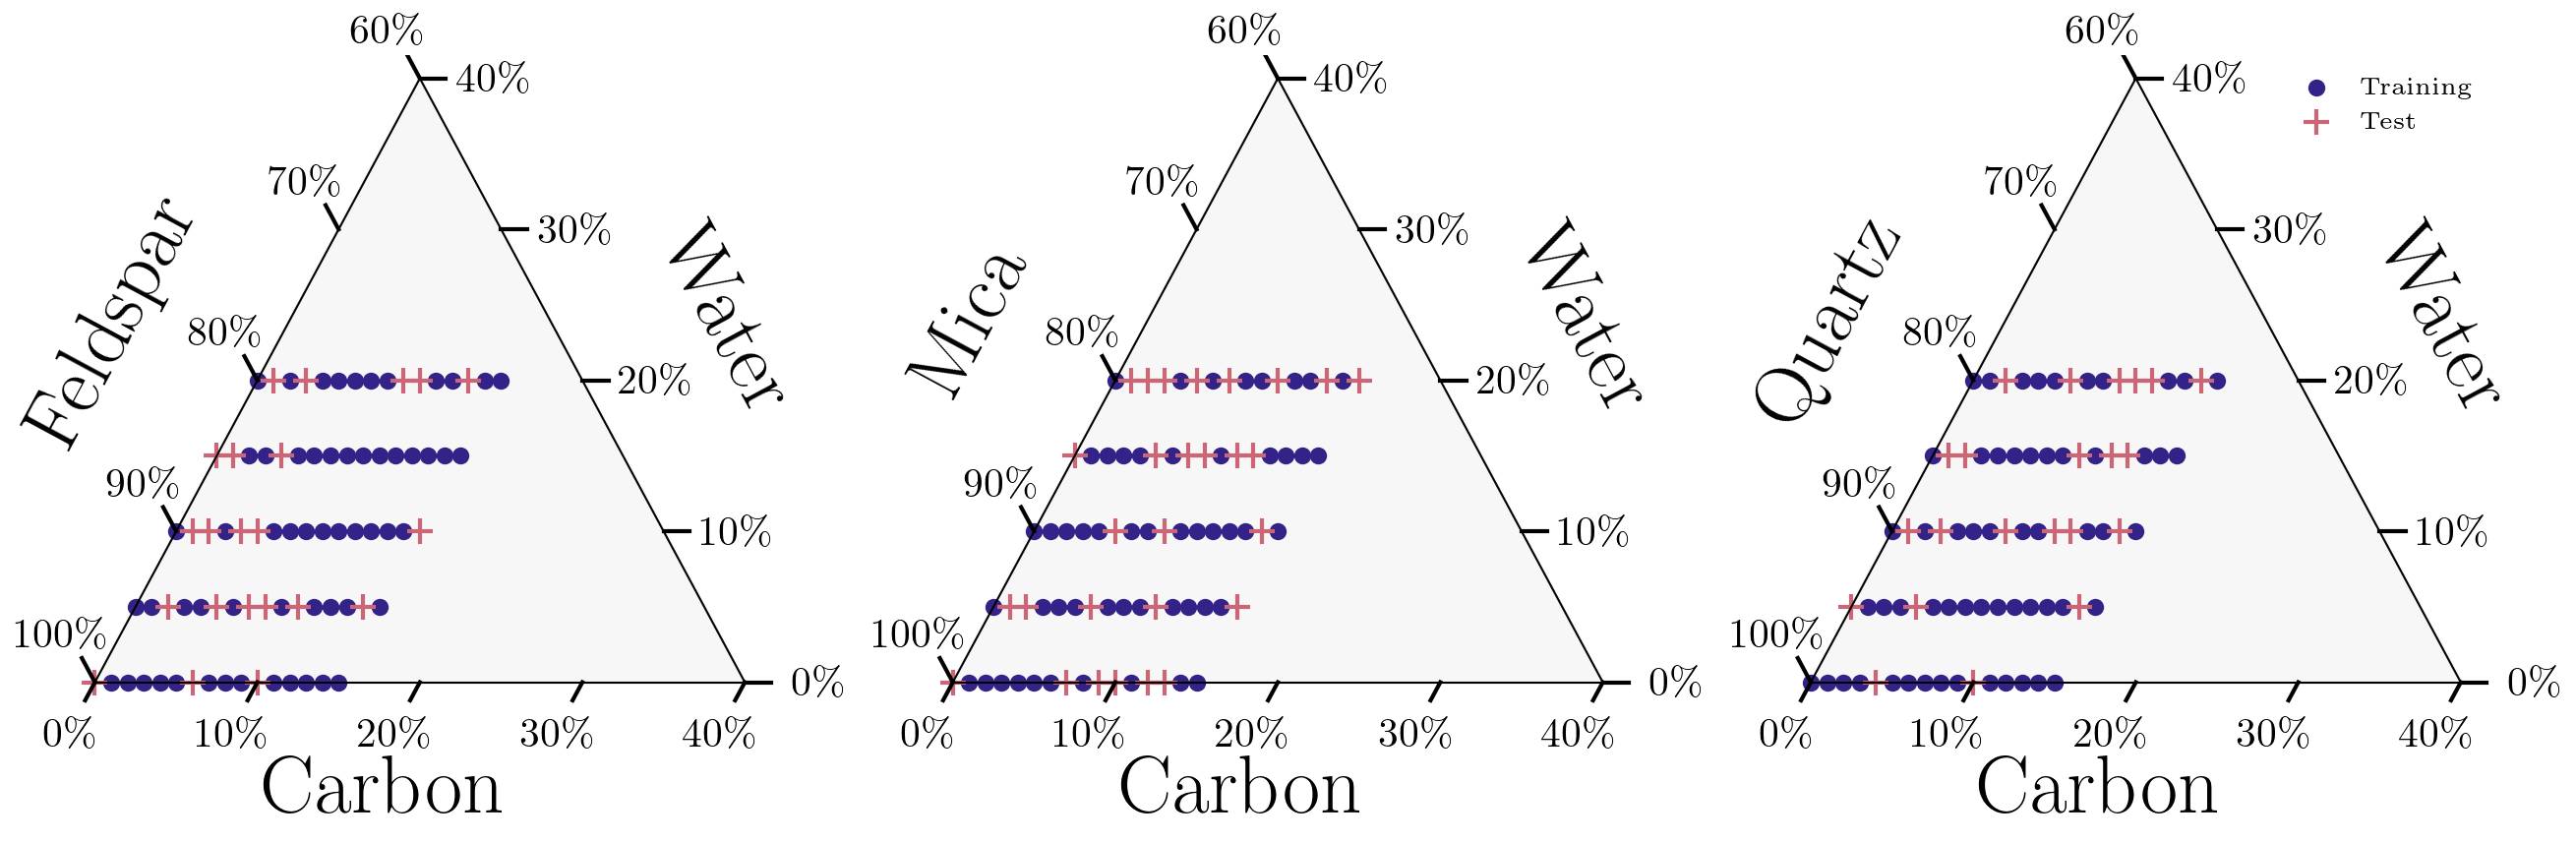

In [186]:
fig, axs = plt.subplots(1, 3, figsize=(3*single_col_width, single_col_width * np.sqrt(3)/2))
tax0 = ternary.TernaryAxesSubplot(ax=axs[0], scale=0.4)
tax0.boundary(linewidth=0.5)
tax1 = ternary.TernaryAxesSubplot(ax=axs[1], scale=0.4)
tax1.boundary(linewidth=0.5)
tax2 = ternary.TernaryAxesSubplot(ax=axs[2], scale=0.4)
tax2.boundary(linewidth=0.5)
taxs = [tax0, tax1, tax2]
for i in range(len(carbons)):
    material = materials[i]
    # style = carbon_styles[material]
    taxs[unique_materials.index(material)].scatter(
        [(carbons[i], hydrations[i], material_levels[i])], 
        marker=markers[masks[i]],
        color=colors[masks[i]], 
        label=masks[i],
        s=40
        )
legend_handles = [
    plt.scatter([], [], marker=markers['Training'], color=colors['Training'], s=40, label='Training'),
    plt.scatter([], [], marker=markers['Test'], color=colors['Test'], s=40, label='Test')
]
for i, ax in enumerate(axs):
    ax.axis('off')
    taxs[i].left_corner_label(
        unique_materials[i],
        # fontsize=20,
        offset=0.4,
        position=(-.25, 0.7, 0),
        fontweight='bold',
        rotation=60
    )
    taxs[i].right_corner_label("Carbon", offset=1, position=(0.5, -.1, 0), fontweight='bold')
    taxs[i].top_corner_label("Water", offset=0.26, position=(.55, .7, 0), fontweight='bold', rotation=-60)
    taxs[i].ticks(
        ticks=['0\%', '10\%', '20\%', '30\%', '40\%'],
        locations= [0, .1, .2, .3, .4],
        axis='r',
        linewidth=1,
        multiple=.05,  # or 0.1 for less crowded ticks
        # fontsize=8,
        offset=0.04,
        # tick_formats="%.2f",
        # clockwise=True  # two decimals for small scale
    )
    taxs[i].ticks(
        ticks=['0\%', '10\%', '20\%', '30\%', '40\%'],
        locations= [0, .1, .2, .3, .4],
        axis='b',
        linewidth=1,
        multiple=0.05,  # or 0.1 for less crowded ticks
        # fontsize=8,
        offset=0.03,
        # tick_formats="%.2f"  # two decimals for small scale
        
    )
    taxs[i].ticks(
        ticks = ['60\%', '70\%', '80\%', '90\%', '100\%'],
        locations= [0, .1, .2, .3, .4],
        axis='l',
        linewidth=1,
        multiple=.1,  # or 0.1 for less crowded ticks
        # fontsize=8,
        offset=0.04,
        # tick_formats="%.2f",  # two decimals for small scale
        # clockwise=True

    )
    # ax.set_title(unique_materials[i], fontsize=12, pad=20)



tax2.legend(handles=legend_handles, loc='upper right', fontsize=6)
plt.savefig(figure_folder + 'traintestsplit.jpg', dpi=300, bbox_inches='tight')
plt.show()
# tax2.legend(['Training', 'Test'], loc='upper right', fontsize=6)